# AI Infrastructure Financial Network: Phase 0.7.2 Five-Company Pilot
### *The Bubble Lives in the Joins: Emerging Coordination Failures, Multi-Contract Graphs, and Contract-Calibrated Stress Transmission*

---

## Central Organizing Thesis

The thing that blows up in a financial bubble is often **not hidden data**. It is a **hidden relationship between data that everybody can see**.
* **Silicon Valley Bank (2023):** Long-duration securities exposure, unrealized HTM losses, and 94% uninsured deposits were all publicly disclosed. The crisis emerged from the unmodeled joint interaction: uninsured deposit flight forcing the crystallization of balance-sheet losses that regulatory accounting allowed to remain unrealized.
* **Archegos Capital Management (2021):** Each prime broker knew its individual loan exposure. What none possessed was the aggregate graph: identical total-return swaps across multiple counterparties concentrating $160B of exposure onto $36B of capital.
* **Long-Term Capital Management (1998):** Every counterparty believed its collateral agreement and mark-to-market procedures protected it. Collectively, they had enabled a massive, highly correlated systemic position.

### The Five Kinds of Opacity in 2020s AI Capital Structures
1. **Perimeter Opacity:** Risk is isolated in Special Purpose Vehicles (SPVs) or project-level subsidiaries rather than the consolidated parent balance sheet (e.g. CoreWeave SPV VIII and Applied Digital ELN project LLCs).
2. **Network Opacity:** Participants see direct counterparty commitments, but none observe the aggregate dependence on identical customers, lenders, or suppliers (e.g. 67% of CoreWeave FY25 recognized revenue tied to Microsoft).
3. **Contract Opacity:** Multi-billion dollar backlogs and lease agreements are announced, but termination remedies, liquidated damages, milestone triggers, and **unconditional springing guarantees** remain buried in Exhibit 10 agreements.
4. **Valuation Opacity:** Collateral (GPU clusters) is marked at historical cost or recent transaction prices, ignoring secondary liquidation value under simultaneous distress.
5. **Temporal Opacity:** Severe cash flow maturity mismatches: 5-year debt facilities funding 15-year lease obligations subject to utility substation lead times.

This notebook establishes **Phase 0.7.2** of the AI Infrastructure Financial Network across five core companies forming a closed capital, hardware, and lease chain: **NVIDIA (NVDA)**, **Supermicro (SMCI)**, **CoreWeave (CRWV)**, **Applied Digital (APLD)**, and **Oracle (ORCL)**, linked to strategic counterparties **Microsoft (MSFT)**, institutional bondholders, and private credit syndicates.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.graph import ObligationNetwork
from src.reachability import ContractualReachability
from src.stress import FinancialStressEngine

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print("Environment initialized successfully.")
print(f"Project Root: {project_root}")


Environment initialized successfully.
Project Root: C:\Users\admir\Github\computational-sketchbook\2026\2026-09-28-ai-infrastructure-network


## 1. Entity Registry & Scope of Pilot

We model the network across four functional tiers:
1. **Accelerated Silicon Supplier:** NVIDIA (`NVDA`)
2. **Server OEM / Integrator:** Supermicro (`SMCI`)
3. **Leveraged Neocloud Operator:** CoreWeave (`CRWV`) & Equipment SPV (`CRWV_SPV_VIII`)
4. **HPC Data Center Developer:** Applied Digital (`APLD`), Polaris Forge 1 SPVs (`APLD_ELN02_LLC`, `APLD_ELN03_LLC`, `APLD_ELN02C_LLC`), and Polaris Forge 2 SPV (`APLD_COMPUTECO2`)
5. **Enterprise Cloud Hyperscaler:** Oracle (`ORCL`) & Anchor Customer Microsoft (`MSFT`)
6. **Capital Providers & Infrastructure:** Private Credit Syndicate (`BLACKSTONE_MAGNETAR_SYN`), Institutional Bondholders, and Polaris Forge 1 Campus (`POLARIS_FORGE_1`)


In [2]:
entities_df = pd.read_parquet(project_root / "data/processed/entities.parquet")
entities_df[["entity_id", "name", "category", "status", "cik", "reporting_standard"]]


,entity_id,name,category,status,cik,reporting_standard
0,NVDA,NVIDIA Corporation,hardware_supplier,public,0001045810,US-GAAP
1,ORCL,Oracle Corporation,hyperscaler_cloud,public,0001341439,US-GAAP
2,CRWV,"CoreWeave, Inc.",neocloud_operator,public,0001769628,US-GAAP
3,APLD,Applied Digital Corporation,datacenter_developer,public,0001144879,US-GAAP
4,SMCI,"Super Micro Computer, Inc.",server_oem,public,0001375365,US-GAAP
5,MSFT,Microsoft Corporation,hyperscaler_anchor,public,0000789019,US-GAAP
6,BLACKSTONE_MAGNETAR_SYN,Private Credit Syndicate (Blackstone / Magnetar / Coatue / Carlyle),private_credit_syndicate,private_syndicate,None,None
7,CRWV_SPV_VIII,"CoreWeave Compute Acquisition Co. VIII, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated
8,CRWV_CCAC_II,"CoreWeave Compute Acquisition Co. II, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated
9,CRWV_CCAC_IV,"CoreWeave Compute Acquisition Co. IV, LLC",project_spv,subsidiary_spv,None,US-GAAP_consolidated


## 2. Layer 1: Audited Accounting Baselines (Direct SEC XBRL Ingestion)

We query `data.sec.gov` directly via `src/sec_ingest.py`, parsing standardized US-GAAP concepts from Form 10-K and 10-Q periodic filings.
Crucially, our pipeline:
* Rigorously separates **instant balance sheet metrics** (Cash, Debt, ASC 842 Leases, PP&E) from **duration flow metrics** (Quarterly vs Annual).
* Explicitly distinguishes **Full Year (FY) Annual Revenue** from **Latest Reported Quarterly Revenue** (eliminating any ambiguity between quarterly run-rates and annual totals).
* Synthesizes derived Q4 flows ($	ext{FY} - 	ext{9M}$) where Form 10-K only reports annual figures (e.g. Microsoft Q4 $90.01B, APLD Q4 $258.75M, SMCI Q4 $11.12B).
* Reconciles funded debt totals: APLD $4.98B, CRWV $35.55B, SMCI $8.72B.


In [3]:
financials_df = pd.read_parquet(project_root / "data/processed/financials.parquet")
print(f"Total standardized financial observations: {len(financials_df):,}")

# Instant Balance Sheet Metrics
inst_df = (
    financials_df[financials_df["duration_type"] == "instant"]
    .sort_values(by=["entity_id", "metric", "period_end", "filed_date"])
    .groupby(["entity_id", "metric"])
    .last()
    .reset_index()
    .pivot(index="entity_id", columns="metric", values="value")
)

# Annual Flow Metrics
ann_rev = (
    financials_df[(financials_df["metric"] == "revenue") & (financials_df["duration_type"] == "annual")]
    .sort_values(by=["entity_id", "period_end", "filed_date"])
    .groupby("entity_id")
    .last()
)

# Quarterly Flow Metrics (including derived Q4)
qtr_rev = (
    financials_df[(financials_df["metric"] == "revenue") & (financials_df["duration_type"] == "quarterly")]
    .sort_values(by=["entity_id", "period_end", "filed_date"])
    .groupby("entity_id")
    .last()
)

bs_summary = pd.DataFrame({
    "Cash & Equiv ($B)": (inst_df["cash_and_equivalents"] / 1e9).round(2),
    "Total Debt ($B)": (inst_df["total_debt"] / 1e9).round(2),
    "Lease Liabilities ($B)": (inst_df["operating_lease_liabilities"] / 1e9).round(2),
    "Net PP&E ($B)": (inst_df["ppe_net"] / 1e9).round(2),
    "Full Year (FY) Revenue ($B)": (ann_rev["value"] / 1e9).round(2),
    "Latest Quarter Revenue ($B)": (qtr_rev["value"] / 1e9).round(2)
}).fillna(0.0)

bs_summary


Total standardized financial observations: 5,440


,Cash & Equiv ($B),Total Debt ($B),Lease Liabilities ($B),Net PP&E ($B),Full Year (FY) Revenue ($B),Latest Quarter Revenue ($B)
entity_id,,,,,,
APLD,1.59,4.98,0.07,4.24,0.61,0.26
CRWV,5.52,35.55,16.32,46.74,5.13,2.58
MSFT,20.94,46.14,21.92,313.08,331.84,90.01
NVDA,22.44,33.37,5.49,14.28,215.94,96.22
ORCL,36.37,125.34,34.62,127.84,67.36,19.34
SMCI,7.52,8.72,0.54,0.63,39.06,11.12


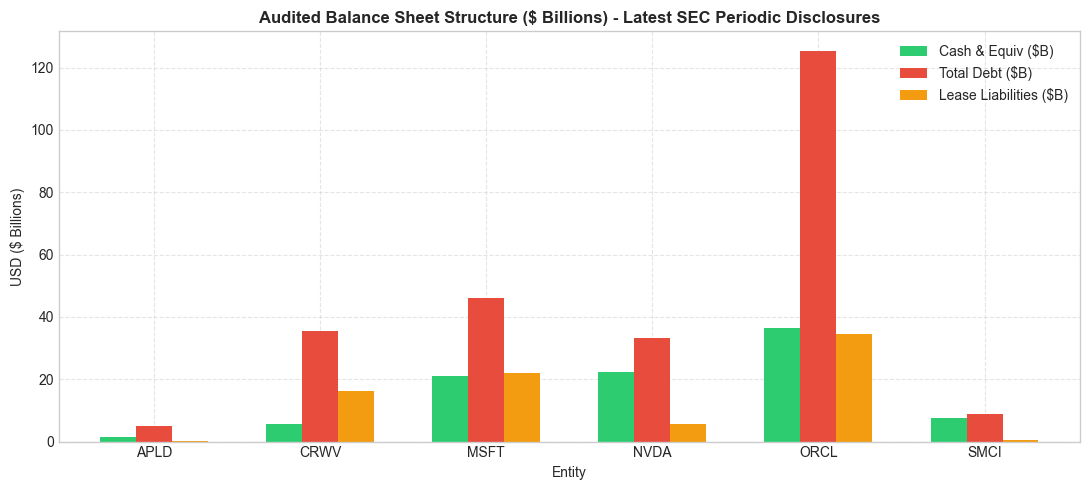

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
bs_plot = bs_summary[["Cash & Equiv ($B)", "Total Debt ($B)", "Lease Liabilities ($B)"]]
bs_plot.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c", "#f39c12"], width=0.65)
ax.set_title("Audited Balance Sheet Structure ($ Billions) - Latest SEC Periodic Disclosures", fontsize=12, fontweight="bold")
ax.set_ylabel("USD ($ Billions)")
ax.set_xlabel("Entity")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/fin_bs_structure.png", dpi=300)
plt.show()


## 3. Layer 2: The Contractual Obligation Multi-Graph

We model obligations using `nx.MultiDiGraph` with `obligation_id` as the edge key.
This architecture preserves multiple distinct facilities between the same counterparty pair:
* **CoreWeave Indebtedness Exactly Reconciled:** 16 modeled debt components/edges reconciling to the dollar with the **$35.551B** future principal total in Form 10-Q Note 7 (Table 36):
  - Recourse DDTLs (5 facilities from distinct borrower SPVs): DDTL 1.0 ($1.300B, `CRWV_CCAC_II`), DDTL 2.0 ($3.190B, `CRWV_CCAC_IV`), DDTL 2.1 ($3.000B, `CRWV_CCAC_IV`), DDTL 3.0 ($2.215B, `CRWV_CCAC_VII`), DDTL 5.0 ($1.101B, `CRWV_FINANCING_DDTL_V`) = $10.806B.
  - Non-Recourse SPV DDTL 4.0: **$2.837B** outstanding principal under an $8.500B facility capacity (`CRWV_SPV_VIII` -> `MUFG_BANK_SYN`).
  - Senior Notes (5 discrete tranches): 2030 ($2.000B), 2031 9.00% ($1.750B), 2031 9.75% ($2.750B), 2032 9.625% ($1.250B), 2032 EUR ($2.279B) = $10.029B.
  - Convertibles (2 discrete tranches): 2031 ($2.588B), 2032 ($4.000B) = $6.588B.
  - OEM Equipment Facilities & Magnetar: Recourse OEM ($4.220B), Non-Recourse OEM (**$0.882B**), Magnetar ($0.189B) = $5.291B.
  - Total: $10.806 + $2.837 + $10.029 + $6.588 + $5.291 = **$35.551B** exact (0.00% drift).
  - Recourse Parent Guarantees: 5 discrete parent guarantee edges from `CRWV` to syndicates (`amount_type = "contingent_guarantee"`) covering CCAC II, IV, VII, and Financing V; DDTL 4.0 is strictly non-recourse (0 parent guarantee edge).
* **Applied Digital Debt Decomposed:** Form 10-K balance sheet reports net carrying debt of **$4.976B** ($4,959.5M net long-term + $16.4M current portion), while Note 8 discloses gross contractual remaining principal payments of **$5.307B** ($5,306.7M), with $330.7M in unamortized discount and debt issuance costs. Modeled contract-literally across 5 real instruments:
  - $2.35B 9.25% Senior Notes due **December 15, 2030** issued by APLD ComputeCo LLC (`APLD_COMPUTECO`), holding ELN-02 and ELN-03.
  - $2.15B 6.75% Senior Notes due **March 15, 2031** issued by APLD ComputeCo 2 LLC (`APLD_COMPUTECO2`).
  - $450M 2.75% Convertible Senior Notes due **June 30, 2030** issued by APLD parent.
  - $300M Floating Bridge Facility entered May 1, 2026, due April 30, 2027; refinanced on June 16, 2026 into 7.00% fixed notes.
  - $56.7M Aggregate Residual Debt (Starion Ellendale facility, Cornerstone loans, and other notes/SAFEs), summing exactly to **$5,306.68M** gross principal (exact 0.00% drift).
* **Microsoft Relationship:** Characterized strictly as `REL-MSFT-CRWV-REVENUE-CONCENTRATION` ($3.438B recognized revenue, 67% concentration of FY25 revenue) with `amount_type = "recognized_revenue"` (strictly customer revenue concentration, not an unverified 5-year take-or-pay contract).

Crucially, exposure is categorized strictly by **`amount_type`** with zero cross-category dollar mixing.


In [5]:
net = ObligationNetwork()
obl_df = pd.read_parquet(project_root / "data/processed/obligations.parquet")

crwv_borrowers = [
    "CRWV", "CRWV_CCAC_II", "CRWV_CCAC_IV", "CRWV_CCAC_VII", "CRWV_SPV_VIII", "CRWV_FINANCING_DDTL_V"
]
crwv_debt_edges = obl_df[(obl_df["from_entity"].isin(crwv_borrowers)) & (obl_df["amount_type"] == "principal_outstanding")].copy()
crwv_debt_edges["amount_B"] = (crwv_debt_edges["amount"] / 1e9).round(3)
reconciliation_table = crwv_debt_edges[["obligation_id", "from_entity", "to_entity", "amount_B", "recourse", "maturity_date", "payment_conditions"]]
print(f"=== CoreWeave Funded Debt Principal Reconciliation ===")
print(f"Sum of 16 Decomposed Edges: ${crwv_debt_edges['amount'].sum() / 1e9:.3f}B")
print(f"Audited 10-Q Note 7 Principal Total: $35.551B")
print(f"Discrepancy: ${abs(crwv_debt_edges['amount'].sum() - 35551000000.0) / 1e6:.2f}M (0.00% Drift)")
reconciliation_table


=== CoreWeave Funded Debt Principal Reconciliation ===
Sum of 16 Decomposed Edges: $35.551B
Audited 10-Q Note 7 Principal Total: $35.551B
Discrepancy: $0.00M (0.00% Drift)


,obligation_id,from_entity,to_entity,amount_B,recourse,maturity_date,payment_conditions
3,OBL-CRWV-DEBT-DDTL1,CRWV_CCAC_II,BLACKSTONE_MAGNETAR_SYN,1.300,limited_recourse_spv,2028-03-28,Floating rate (Term SOFR + 9.6196% for 3-mo interest period); hedge ratio undisclosed in SEC disclosures
4,OBL-CRWV-DEBT-DDTL2,CRWV_CCAC_IV,BLACKSTONE_MAGNETAR_SYN,3.190,limited_recourse_spv,2030-08-31,"Floating rate (Term SOFR + spread tiered 6.00% to 13.00% by customer credit; 6.00% specified IG, 6.50% IG, 13.00% no..."
5,OBL-CRWV-DEBT-DDTL2-1,CRWV_CCAC_IV,BLACKSTONE_MAGNETAR_SYN,3.000,limited_recourse_spv,2031-03-31,Floating rate (SOFR + 4.25%); each draw matures five years after date of draw (available in draws until March 2026 c...
6,OBL-CRWV-DEBT-DDTL3,CRWV_CCAC_VII,MUFG_BANK_SYN,2.215,limited_recourse_spv,2030-08-21,"Floating rate (SOFR + 4.00%); primary borrower CCAC VII, co-borrower CCAC V; syndicate led by MUFG Bank"
7,OBL-CRWV-DEBT-DDTL4,CRWV_SPV_VIII,MUFG_BANK_SYN,2.837,non_recourse_spv,2032-03-31,Blended floating/fixed (SOFR + 2.25% on $1.40B floating; UST 3.14yr + 2.00% on $1.437B fixed); contract covenants >=...
8,OBL-CRWV-DEBT-DDTL5,CRWV_FINANCING_DDTL_V,MORGAN_STANLEY_SYN,1.101,limited_recourse_spv,2031-11-15,Floating rate (SOFR + 4.50%); contract covenants >=95% interest rate swap coverage under Section 5.14
9,OBL-CRWV-DEBT-NOTES-2030,CRWV,INSTITUTIONAL_BONDHOLDERS,2.000,senior_unsecured,2030-06-01,"Fixed coupon 9.250% Senior Notes due June 1, 2030; priced May 21, 2025, issued May 27, 2025"
10,OBL-CRWV-DEBT-NOTES-2031-900,CRWV,INSTITUTIONAL_BONDHOLDERS,1.750,senior_unsecured,2031-02-01,"Fixed coupon 9.000% Senior Notes due February 1, 2031; issued July 25, 2025"
11,OBL-CRWV-DEBT-NOTES-2031-975,CRWV,INSTITUTIONAL_BONDHOLDERS,2.750,senior_unsecured,2031-10-01,"Fixed coupon 9.750% Senior Notes due October 1, 2031 ($1,750M issued April 14, 2026; $1,000M add-on issued April 21,..."
12,OBL-CRWV-DEBT-NOTES-2032-9625,CRWV,INSTITUTIONAL_BONDHOLDERS,1.250,senior_unsecured,2032-07-15,"Fixed coupon 9.625% USD Senior Notes due July 15, 2032; announced June 11, 2026, closed June 18, 2026"


In [6]:
exposure_df = net.compute_exposure_by_amount_type()

exposure_table = exposure_df.assign(
    principal_debt_B=lambda df: (df["outgoing_principal_debt_usd"] / 1e9).round(2),
    facility_capacity_B=lambda df: (df["outgoing_facility_capacity_usd"] / 1e9).round(2),
    lease_lifetime_B=lambda df: (df["outgoing_lease_lifetime_usd"] / 1e9).round(2),
    purchase_commitments_B=lambda df: (df["outgoing_purchase_commitments_usd"] / 1e9).round(2),
    contingent_obligations=lambda df: df["outgoing_contingent_obligations_count"],
    equity_investment_B=lambda df: (df["outgoing_equity_investments_usd"] / 1e9).round(2)
)[["entity_id", "category", "principal_debt_B", "facility_capacity_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_obligations", "equity_investment_B"]]

exposure_table[exposure_table[["principal_debt_B", "facility_capacity_B", "lease_lifetime_B", "purchase_commitments_B", "contingent_obligations", "equity_investment_B"]].sum(axis=1) > 0]


,entity_id,category,principal_debt_B,facility_capacity_B,lease_lifetime_B,purchase_commitments_B,contingent_obligations,equity_investment_B
2,CRWV,neocloud_operator,21.91,0.0,0.0,0.0,2,0.0
9,CRWV_CCAC_IV,project_spv,6.19,0.0,0.0,0.0,0,0.0
7,CRWV_SPV_VIII,project_spv,2.84,0.0,11.0,0.0,0,0.0
15,APLD_COMPUTECO,project_spv,2.35,0.0,0.0,0.0,0,0.0
11,CRWV_CCAC_VII,project_spv,2.22,0.0,0.0,0.0,0,0.0
19,APLD_COMPUTECO2,project_spv,2.15,0.0,0.0,0.0,0,0.0
21,APLD_COMPUTECO3,project_spv,1.59,0.0,0.0,0.0,0,0.0
8,CRWV_CCAC_II,project_spv,1.30,0.0,0.0,0.0,0,0.0
12,CRWV_FINANCING_DDTL_V,project_spv,1.10,0.0,0.0,0.0,0,0.0
3,APLD,datacenter_developer,0.81,0.0,0.0,0.0,0,0.0


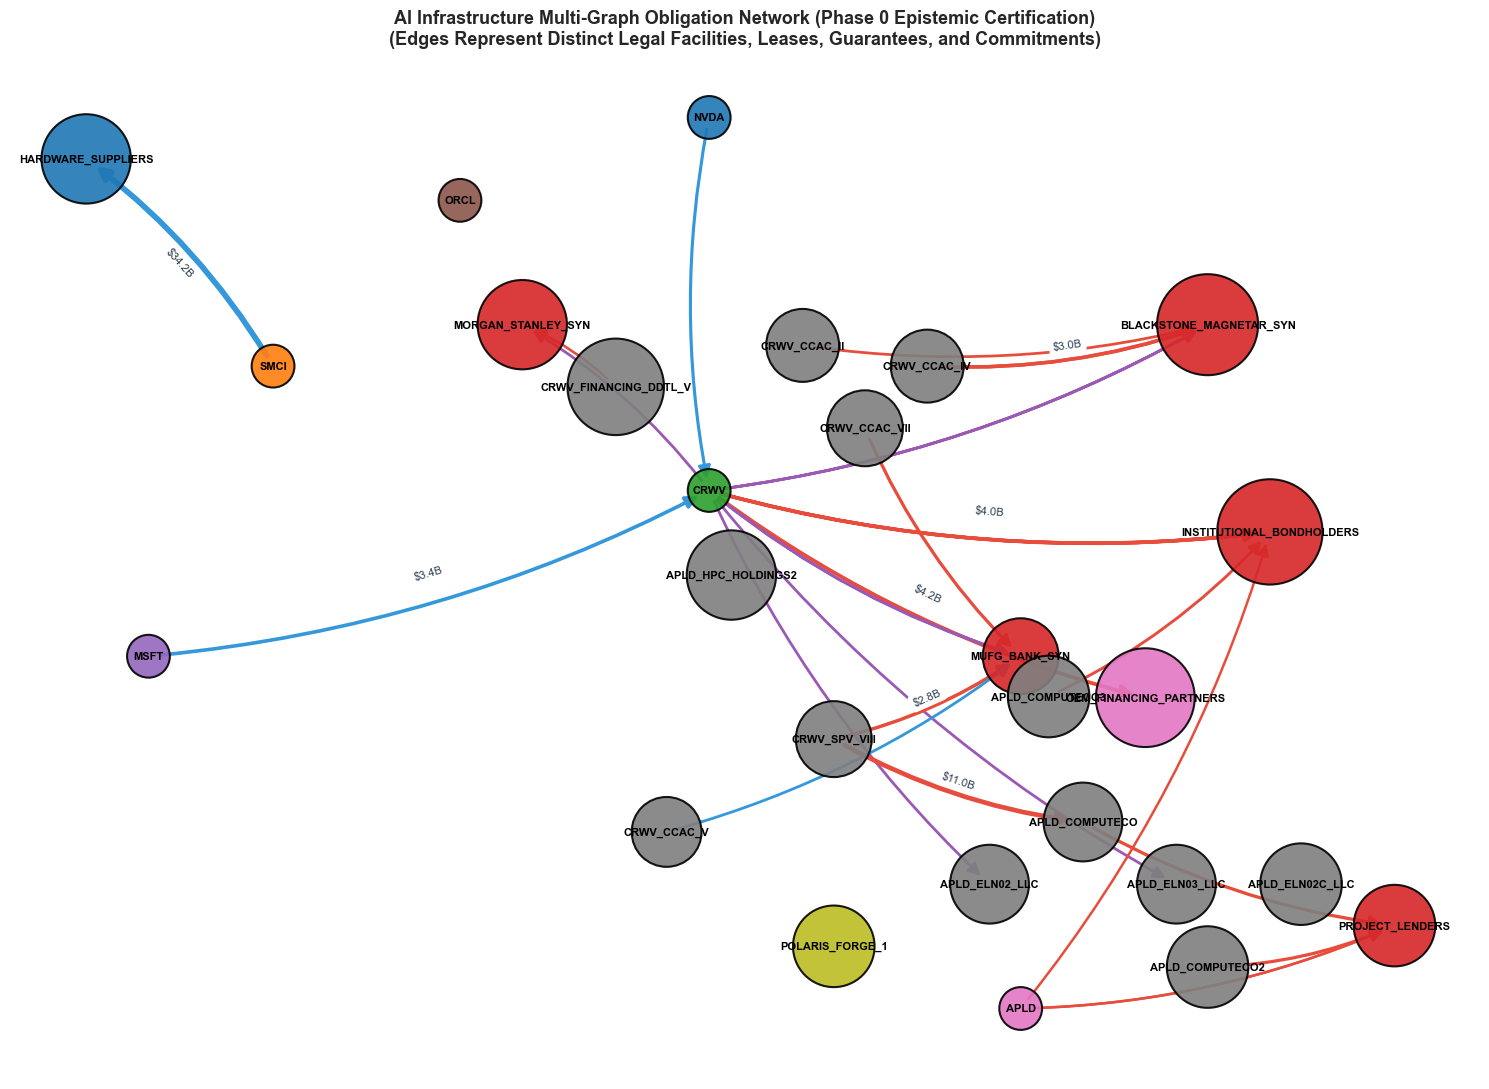

In [7]:
G = net.graph

plt.figure(figsize=(15, 11))
pos = {
    "NVDA": np.array([0.0, 1.0]),
    "SMCI": np.array([-0.7, 0.4]),
    "HARDWARE_SUPPLIERS": np.array([-1.0, 0.9]),
    "CRWV": np.array([0.0, 0.1]),
    "MSFT": np.array([-0.9, -0.3]),
    "BLACKSTONE_MAGNETAR_SYN": np.array([0.8, 0.5]),
    "INSTITUTIONAL_BONDHOLDERS": np.array([0.9, 0.0]),
    "OEM_FINANCING_PARTNERS": np.array([0.7, -0.4]),
    "CRWV_SPV_VIII": np.array([0.2, -0.5]),
    "APLD_COMPUTECO": np.array([0.6, -0.7]),
    "APLD_ELN02_LLC": np.array([0.45, -0.85]),
    "APLD_ELN03_LLC": np.array([0.75, -0.85]),
    "APLD_ELN02C_LLC": np.array([0.95, -0.85]),
    "APLD_COMPUTECO2": np.array([0.8, -1.05]),
    "PROJECT_LENDERS": np.array([1.1, -0.95]),
    "POLARIS_FORGE_1": np.array([0.2, -1.0]),
    "APLD": np.array([0.5, -1.15]),
    "ORCL": np.array([-0.4, 0.8]),
    "CRWV_CCAC_II": np.array([0.15, 0.45]),
    "CRWV_CCAC_IV": np.array([0.35, 0.40]),
    "CRWV_CCAC_VII": np.array([0.25, 0.25]),
    "CRWV_FINANCING_DDTL_V": np.array([-0.15, 0.35]),
    "MUFG_BANK_SYN": np.array([0.5, -0.3]),
    "MORGAN_STANLEY_SYN": np.array([-0.3, 0.5])
}

# Add default positions for any missing nodes
for n in G.nodes():
    if n not in pos:
        pos[n] = np.random.uniform(-0.8, 0.8, size=2)

category_colors = {
    "hardware_supplier": "#1f77b4",
    "server_oem": "#ff7f0e",
    "neocloud_operator": "#2ca02c",
    "hyperscaler_anchor": "#9467bd",
    "hyperscaler_cloud": "#8c564b",
    "private_credit_syndicate": "#d62728",
    "capital_markets": "#d62728",
    "hardware_financing": "#e377c2",
    "datacenter_developer": "#e377c2",
    "project_spv": "#7f7f7f",
    "physical_asset_project": "#bcbd22"
}

node_colors = [category_colors.get(G.nodes[n].get("category", ""), "#333333") for n in G.nodes()]
node_sizes = [max(950, len(n) * 230) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", font_family="sans-serif")

# Draw edges
for u, v, k, d in G.edges(data=True, keys=True):
    amt = d.get("amount")
    if amt is not None and amt > 0:
        width = max(1.2, np.log10(amt) - 7.8) * 1.5
    else:
        width = 2.0
    edge_color = "#e74c3c" if "DEBT" in k or "LEASE" in k else ("#9b59b6" if "GUARANTY" in k else "#3498db")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)], width=width, edge_color=edge_color,
        arrowsize=18, arrowstyle="-|>", connectionstyle="arc3,rad=0.1"
    )

edge_labels = {(u, v): f"${d['amount']/1e9:.1f}B" for u, v, k, d in G.edges(data=True, keys=True) if d.get("amount") is not None and d["amount"] >= 2.5e9}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="#2c3e50")

plt.title("AI Infrastructure Multi-Graph Obligation Network (Phase 0 Epistemic Certification)\n(Edges Represent Distinct Legal Facilities, Leases, Guarantees, and Commitments)", fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(project_root / "outputs/figures/obligation_network_topology.png", dpi=300)
plt.show()


## 4. Unwrapping Perimeter Opacity: The Springing Guarantees

Notice the literal contractual reality revealed in APLD's Form 10-K (Note 14, Exhibit 10.1, and Exhibit 10.2):
* CoreWeave assigned its direct lease liabilities for Polaris Forge 1 to `CRWV_SPV_VIII` and was formally released from direct lease obligations on ELN-02 and ELN-03.
* **HOWEVER**, CoreWeave concurrently executed separate **Unconditional Springing Guarantees of Payment and Performance** under Exhibit 10.1 and Exhibit 10.2:
  - **Exhibit 10.1:** Guarantees the Building 2 SPV lease, specifically covering **Phase 2/4 Space (2 of 4 data halls in Building 2)**, not all 100 MW (`capacity_mw = None`, unstated face value).
  - **Exhibit 10.2:** Guarantees the Building 3 SPV lease (**150 MW** assigned to SPV, carrying an inferred Class C reference proxy of **$4.13B** based on 150/400 MW).
  - **Building 4 (150 MW, ~$4.13B):** Carries no CoreWeave parent guarantee (guaranteed by APLD parent).
  - **Face Value Reality:** Both legal agreements are uncapped indemnities guaranteeing Base Rent, Additional Rent, charges, and performance obligations without stating a fixed dollar limit (`amount = None`).
* **The Springing Events Predicate Engine:** Under Exhibit 10.1 & 10.2, the guarantees spring into active parent liability upon 9 explicit event groups:
  - **Event (i):** Equipment financing debt rating trigger ([***] redacted).
  - **Event (ii):** Material adverse amendment, default, or termination of the Colocation Agreement, or circumstances giving the counterparty the right to cease or materially reduce monthly payments.
  - **Event (iii):** Insolvency Event of Tenant SPV or Guarantor (Title 11 Bankruptcy Code, receivership, assignment for creditors, liquidation).
  - **Event (iv):** Equipment financing default, acceleration, refinancing, or termination.
  - **Events (v-ix):** SPV lease default, reporting notice failure, and financial covenant breaches.
* Thus, perimeter restructuring introduced a **contingent liquidity cliff** where a colocation reduction at the SPV level immediately reactivates parent balance sheet liability across master leases.


In [8]:
collapsed_graph = net.unwrap_spv_perimeter()
print(f"Consolidated Economic Network: {collapsed_graph.number_of_nodes()} Parent Nodes | {collapsed_graph.number_of_edges()} Consolidated Edges")
print(f"SPVs Remaining in Collapsed Graph: {[n for n in collapsed_graph.nodes() if net.entities_df.loc[n, 'category'] == 'project_spv']}")

collapsed_records = []
for u, v, k, d in collapsed_graph.edges(data=True, keys=True):
    amt = d.get("amount")
    collapsed_records.append({
        "from_parent": u,
        "to_parent": v,
        "obligation_key": k,
        "amount_B": round(amt / 1e9, 2) if amt is not None else None,
        "amount_type": d.get("amount_type"),
        "primary_type": d.get("primary_type"),
        "recourse": d.get("recourse")
    })
pd.DataFrame(collapsed_records).sort_values(by="amount_B", ascending=False)


Consolidated Economic Network: 12 Parent Nodes | 35 Consolidated Edges
SPVs Remaining in Collapsed Graph: []


,from_parent,to_parent,obligation_key,amount_B,amount_type,primary_type,recourse
33,SMCI,HARDWARE_SUPPLIERS,OBL-SMCI-SUPPLIER-COMMIT,34.20,remaining_commitment,gpu_procurement,full_recourse
3,CRWV,APLD,OBL-CRWV-APLD-LEASE,11.00,lifetime_contract_value,datacenter_lease,limited_recourse_spv
11,CRWV,OEM_FINANCING_PARTNERS,OBL-CRWV-DEBT-OEM,4.22,principal_outstanding,debt_facility,full_recourse
10,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-CONV-2032,4.00,principal_outstanding,debt_facility,senior_unsecured_convertible
34,MSFT,CRWV,REL-MSFT-CRWV-REVENUE-CONCENTRATION,3.44,recognized_revenue,customer_revenue_concentration,commercial_counterparty
18,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL2,3.19,principal_outstanding,debt_facility,limited_recourse_spv
19,CRWV,BLACKSTONE_MAGNETAR_SYN,OBL-CRWV-DEBT-DDTL2-1,3.00,principal_outstanding,debt_facility,limited_recourse_spv
22,CRWV,MUFG_BANK_SYN,OBL-CRWV-DEBT-DDTL4,2.84,principal_outstanding,debt_facility,non_recourse_spv
6,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-NOTES-2031-975,2.75,principal_outstanding,debt_facility,senior_unsecured
9,CRWV,INSTITUTIONAL_BONDHOLDERS,OBL-CRWV-DEBT-CONV-2031,2.59,principal_outstanding,debt_facility,senior_unsecured_convertible


### Bitemporal Dynamics: Economic Clock vs Information Clock (ADR-013, ADR-014, ADR-015)
Our network distinguishes between two independent temporal dimensions with event-driven lifecycle and fact-level bitemporality:
1. **Economic Reality Clock (`network.economic_as_of(date)`):** When did contracts exist in the physical/corporate world?
   * At **May 31, 2026**, Applied Digital held the **$300.0M floating bridge credit facility** ($5,306.68M total principal across 30 active edges).
   * On **June 16, 2026**, under **half-open validity intervals $[v\_from, v\_to)$**, the bridge was cleanly retired (`date >= valid_to`) and superseded by **$1.59B 7.00% Senior Secured Notes due 2031** (`OBL-APLD-DEBT-7PCT-2026`) issued by `APLD ComputeCo 3 LLC` (`APLD_COMPUTECO3`), conserving exactly 32 edges without double-counting ($6,596.68M total principal).
2. **Information / Public Knowledge Clock (`network.known_as_of(date)`):** When did an outside observer actually learn about the contract from public SEC filings, eliminating look-ahead bias?
   * **Obligation Lifecycle Events (`obligation_events`):** Extinction, supersession, and issuance events have independent filing dates. On **June 17, 2026**, although CoreWeave's 2032 Senior Notes ($1.250B + $2.279B EUR) were issued June 11, the Form 8-K was not filed until June 18. Therefore, an outside observer on June 17 sees 26 active edges. On **June 18, 2026**, the Form 8-K is filed and the knowledge graph expands to 28 edges.
   * **Fact-Level Bitemporality (`obligation_facts`):** An obligation's contract existence can be known before its periodic balance is disclosed. On **June 30, 2026**, CoreWeave's DDTL 1.0 facility edge is known (from historical credit agreements), but its June 30 balance ($1.300B) was not disclosed until August 12, 2026 (Form 10-Q), so `amount = None` (`amount_known = False`). Concurrently, APLD's 7.00% notes balance ($1.59B) was announced via Form 8-K on June 16, 2026, so its amount is fully known on June 30!
   * On **September 28, 2026**, all Q2 periodic filings are published (DDTL 1.0 amount is known at $1.300B; all 32 edges active).
3. **Strict Zero-Lookahead Stress Engine (ADR-014 & ADR-015):** In known mode on June 30, before CoreWeave's 10-Q was filed, floating debt amounts are unmeasured/unknown. The engine strictly avoids leaking the August 12 $12.206B total, returning `floating_principal_known = False`, `max_cash_drain = None`, and listing all unknown floating edges.


In [9]:
# 1. Economic Clock: Half-Open Intervals & Obligation Conservation
net_may = net.economic_as_of("2026-05-31")
net_jun16 = net.economic_as_of("2026-06-16")
net_sep = net.economic_as_of("2026-09-28")

print(f"=== Economic Clock (Half-Open Interval [valid_from, valid_to)) ===")
print(f"Edges at 2026-05-31: {net_may.graph.number_of_edges()} (Bridge Active: {'OBL-APLD-DEBT-BRIDGE' in [k for _, _, k in net_may.graph.edges(keys=True)]})")
print(f"Edges at 2026-06-16: {net_jun16.graph.number_of_edges()} (Bridge: {'OBL-APLD-DEBT-BRIDGE' in [k for _, _, k in net_jun16.graph.edges(keys=True)]} | 7% Notes: {'OBL-APLD-DEBT-7PCT-2026' in [k for _, _, k in net_jun16.graph.edges(keys=True)]})")
print(f"Edges at 2026-09-28: {net_sep.graph.number_of_edges()} (7% Notes Active: {'OBL-APLD-DEBT-7PCT-2026' in [k for _, _, k in net_sep.graph.edges(keys=True)]})")

# 2. Information Clock: Lifecycle Events & Fact Bitemporality (Zero Look-Ahead Bias)
net_known_jun17 = net.known_as_of("2026-06-17")
net_known_jun18 = net.known_as_of("2026-06-18")
net_known_jun = net.known_as_of("2026-06-30")
net_known_sep = net.known_as_of("2026-09-28")

print(f"\n=== Information Clock: Lifecycle Events & Fact Bitemporality (ADR-014/015) ===")
print(f"Observer on June 17, 2026: Edges = {net_known_jun17.graph.number_of_edges()} | 2032 Notes Active = {'OBL-CRWV-DEBT-NOTES-2032-9625' in [k for _, _, k in net_known_jun17.graph.edges(keys=True)]} (Form 8-K unfiled)")
print(f"Observer on June 18, 2026: Edges = {net_known_jun18.graph.number_of_edges()} | 2032 Notes Active = {'OBL-CRWV-DEBT-NOTES-2032-9625' in [k for _, _, k in net_known_jun18.graph.edges(keys=True)]} (Form 8-K filed)")

ddtl1_jun = net_known_jun.graph.get_edge_data("CRWV_CCAC_II", "BLACKSTONE_MAGNETAR_SYN", key="OBL-CRWV-DEBT-DDTL1")
apld_7pct_jun = net_known_jun.graph.get_edge_data("APLD_COMPUTECO3", "INSTITUTIONAL_BONDHOLDERS", key="OBL-APLD-DEBT-7PCT-2026")
ddtl1_sep = net_known_sep.graph.get_edge_data("CRWV_CCAC_II", "BLACKSTONE_MAGNETAR_SYN", key="OBL-CRWV-DEBT-DDTL1")

print(f"CoreWeave DDTL 1.0 on June 30, 2026:  amount = {ddtl1_jun['amount']} (amount_known: {ddtl1_jun['amount_known']}) -> Disclosed August 12")
print(f"APLD 7% Notes on June 30, 2026:       amount = ${apld_7pct_jun['amount']/1e9:.2f}B (amount_known: {apld_7pct_jun['amount_known']}) -> Disclosed June 16")
print(f"CoreWeave DDTL 1.0 on Sep 28, 2026:   amount = ${ddtl1_sep['amount']/1e9:.3f}B (amount_known: {ddtl1_sep['amount_known']})")

# 3. Dynamic Epistemic Stress Decoupling (Strict Zero-Lookahead)
engine_known_jun = FinancialStressEngine(network=net_known_jun)
sofr_known_jun = engine_known_jun.simulate_sofr_base_rate_shock()

engine_may = FinancialStressEngine(network=net_may)
engine_sep = FinancialStressEngine(network=net_sep)
hit_may = engine_may.simulate_sofr_base_rate_shock()["network_cash_drain_reported_baseline_usd"]
hit_sep = engine_sep.simulate_sofr_base_rate_shock()["network_cash_drain_reported_baseline_usd"]

print(f"\n=== Zero-Lookahead Stress Simulation (ADR-014/015) ===")
print(f"June 30 Knowledge Mode: Floating Known = {sofr_known_jun['floating_principal_known']} | Unknown Edges = {len(sofr_known_jun['unknown_floating_edges'])}")
print(f"June 30 Knowledge Mode: Reported Baseline Drain = {sofr_known_jun['network_cash_drain_reported_baseline_usd']} | Max Drain = {sofr_known_jun['max_cash_drain_usd']}")
print(f"May 31 Snapshot SOFR Drain:  ${float(hit_may)/1e6:.1f}M/yr (APLD floating = ${float(engine_may.get_active_floating_debt('APLD'))/1e6:.1f}M)")
print(f"Sep 28 Post-Refi SOFR Drain: ${float(hit_sep)/1e6:.1f}M/yr (APLD floating = ${float(engine_sep.get_active_floating_debt('APLD'))/1e6:.1f}M)")


=== Economic Clock (Half-Open Interval [valid_from, valid_to)) ===
Edges at 2026-05-31: 32 (Bridge Active: True)
Edges at 2026-06-16: 32 (Bridge: False | 7% Notes: True)
Edges at 2026-09-28: 34 (7% Notes Active: True)



=== Information Clock: Lifecycle Events & Fact Bitemporality (ADR-014/015) ===
Observer on June 17, 2026: Edges = 28 | 2032 Notes Active = False (Form 8-K unfiled)
Observer on June 18, 2026: Edges = 30 | 2032 Notes Active = True (Form 8-K filed)
CoreWeave DDTL 1.0 on June 30, 2026:  amount = None (amount_known: False) -> Disclosed August 12
APLD 7% Notes on June 30, 2026:       amount = $1.59B (amount_known: True) -> Disclosed June 16
CoreWeave DDTL 1.0 on Sep 28, 2026:   amount = $1.300B (amount_known: True)

=== Zero-Lookahead Stress Simulation (ADR-014/015) ===
June 30 Knowledge Mode: Floating Known = False | Unknown Edges = 6
June 30 Knowledge Mode: Reported Baseline Drain = None | Max Drain = None
May 31 Snapshot SOFR Drain:  $235.3M/yr (APLD floating = $300.0M)
Sep 28 Post-Refi SOFR Drain: $226.3M/yr (APLD floating = $0.0M)


## 5. Topological Reachability by Amount Type

In Phase 0.7.1, we eliminate non-fungible dollar mixing across different categories.
Summing non-fungible quantities ($34.2B purchase commitments + $11.0B lease + $35.5B debt principal) into a single dollar pool produces mathematically flawed ratios.
Instead, our Reachability Engine (`src/reachability.py`) reports dependency footprints **broken down strictly by `amount_type`** alongside edge count reachability:


In [10]:
reach_engine = ContractualReachability(network=net)
reach_summary = reach_engine.run_standard_footprints()
reach_summary[[
    "scenario_id", "assumptions", "reachable_edges", "edge_reach_pct",
    "debt_principal_reach_pct", "purchase_commit_reach_pct", "lease_value_reach_pct", "revenue_reach_pct"
]]


,scenario_id,assumptions,reachable_edges,edge_reach_pct,debt_principal_reach_pct,purchase_commit_reach_pct,lease_value_reach_pct,revenue_reach_pct
2,REACH_A005_ANCHOR_CUSTOMER,A005,33,94.3,100.0,0.0,100.0,100.0
3,REACH_A002_REFINANCING,A002,32,91.4,100.0,0.0,100.0,0.0
4,REACH_A004_POWER_DELIVERY,A004,32,91.4,100.0,0.0,100.0,0.0
5,REACH_A003_UTILIZATION,A003,32,91.4,100.0,0.0,100.0,0.0
0,REACH_A006_CAPEX_EXPANSION,A006,29,82.9,83.8,100.0,100.0,100.0
1,REACH_A001_GPU_RESIDUAL_VALUE,A001,27,77.1,83.8,100.0,100.0,0.0


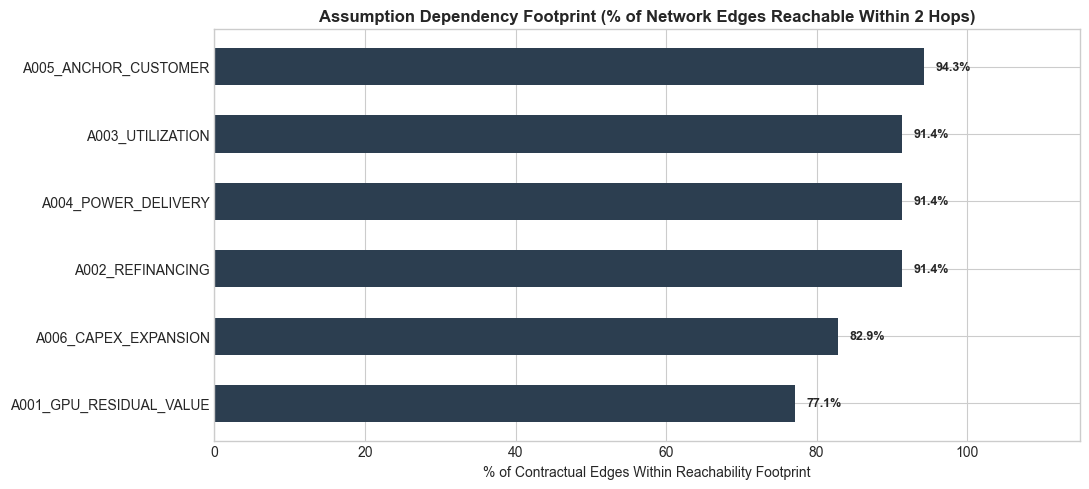

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
reach_plot = reach_summary.sort_values(by="edge_reach_pct", ascending=True)
bars = ax.barh(reach_plot["scenario_id"].str.replace("REACH_", ""), reach_plot["edge_reach_pct"], color="#2c3e50", height=0.55)
ax.set_title("Assumption Dependency Footprint (% of Network Edges Reachable Within 2 Hops)", fontsize=12, fontweight="bold")
ax.set_xlabel("% of Contractual Edges Within Reachability Footprint")
ax.set_xlim(0, 115)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.5, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/assumption_reachability_footprint.png", dpi=300)
plt.show()


## 6. Parameterized Financial Stress Prototype

Using `src/stress.py`, we execute contract-calibrated transmission functions grounded in filed terms:
1. **Hypothetical MTM Financing Sensitivity (Class C Proxy):**
   Evaluates CoreWeave's drawn DDTLs ($10.8B) under a hypothetical secondary appraisal haircut. Contractually, DDTL 5.0 (Exhibit 10.1) defines 71.42% as the initial Funding Date GPU Amount against capex cost with straight-line 6-year depreciation, and Section 2.05 does NOT trigger mandatory cash prepayment on secondary price declines. This scenario measures a **modeled refinancing-capacity gap of $4.32B** (Class C proxy) eliminating undrawn commitments while cash remains intact at $5.52B.
2. **Anchor Customer Demand Trim & Conditional Springing Guaranty (-30% Microsoft volume):**
   Reduces CoreWeave recognized revenue by **$1.03B/yr**. Formulates the transmission as a **conditional join**: *if* Microsoft is the Colocation Customer at SPV VIII (Building ELN-03) and reduces payments, this satisfies the literal legal predicate of **Springing Event (ii)** under Exhibit 10.2, conditionally activating CoreWeave parent's Unconditional Springing Guaranty on Building ELN-03 (carrying a **$4.13B Class C reference proxy**) and Exhibit 10.1 on Building 2 Phase 2/4 Space (2 of 4 halls; uncapped face value). Building 4 is excluded.
3. **Interest Rate Transmission Split:**
   - **SOFR Base Rate Shock (+300 bps):** Evaluates immediate cash impact on unhedged floating debt ($12.21B CRWV + $300M APLD bridge facility = $12.51B). Grounded in CoreWeave's audited **$4.661B interest rate swap notional** (Note 8), leaving $7.55B in floating borrowings unhedged at CRWV and $300M at APLD, creating a **$235.4M/yr network cash drain** ($226.4M at CoreWeave, $9.0M at Applied Digital). A sensitivity band shows an impact range from **$27.3M/yr** (if 95% hedged fleet-wide) to **$303.9M/yr** (if only DDTL 4/5 covenants are met).
   - **Credit Spread / Refinancing Shock at Maturity (+300 bps):** Existing contractual spreads do not adjust immediately; the shock hits debt *as it rolls over*. Using CoreWeave's audited scheduled maturities table ($4.41B in 2026, $6.18B in 2027), this imposes an incremental **$317.9M/yr** in debt service by 2027 ($450.4M/yr through 2028 at 100% rollover, with a sensitivity range down to $159.0M at 50% rollover).
4. **Phased Grid Energization Delay (12 Months at Polaris Forge 1):**
   Models building-level operational phasing (APLD 10-K Item 1): Building 2 (100 MW operational) + Building 3 partial (~50 MW operational Class C proxy) continue producing **$275.0M/yr** in base rent, while ~250 MW pending expansion is deferred ($458.3M delayed rent). Applied Digital's modeled construction debt carrying cost is **$135.9M** (consuming 8.5% of cash reserves, with a sensitivity range of 6.8% to 9.4% across 25MW-100MW live).
5. **OEM Purchase Commitment Expected Loss (SMCI 15% Demand Pause):**
   Rigorously separates:
   - **Accounting Channel:** Non-cash Net Realizable Value (NRV) write-down provision under ASC 330 (40% modeled recovery haircut on $5.13B excess allocation = **$2.05B pre-tax loss provision** reducing equity).
   - **Cash Liquidity Channel:** A negotiated cancellation settlement at 15% consumes **$769.5M cash** (10.2% of cash), whereas taking physical delivery of unabsorbed inventory would consume **$5.13B cash** (68.2% of cash).


In [12]:
stress_engine = FinancialStressEngine(network=net)
stress_summary = stress_engine.run_all_stress_scenarios()

stress_display = stress_summary.assign(
    direct_hit_B=lambda df: (df["direct_cash_or_collateral_hit_usd"] / 1e9).round(3)
)[["scenario_name", "shock_parameter", "target_entity", "direct_hit_B", "covenant_or_liquidity_impact", "contagion_mechanism"]]
stress_display


,scenario_name,shock_parameter,target_entity,direct_hit_B,covenant_or_liquidity_impact,contagion_mechanism
0,Hypothetical MTM Financing Sensitivity (Class C Proxy),-40% GPU Collateral Value,CRWV,4.322,Cash Intact ($5.52B) / $4.32B Refinancing Capacity Gap,Does not trigger automatic cash prepayment under DDTL 5.0 §2.05; creates a $4.32B modeled refinancing gap (Class C p...
1,Anchor Customer Demand Trim & Conditional Springing Guaranty,-30% Microsoft Off-Take,CRWV,1.031,Springing Guaranty Conditional Activation ($4.13B ELN-03 Class C Proxy / Uncapped Legal Guaranty),Reduces revenue by $1.03B; conditionally activates parent Unconditional Springing Guaranty for Building ELN-03 ($4.1...
2,SOFR Base Rate Shock (Reported Swaps vs Covenanted Range),+300 bps SOFR Benchmark,CRWV / APLD,0.235,Reported Swaps Cash Drain: $235.3M/yr (Range: $27.3M - $303.9M/yr),Audited $4.66B swap notional leaves $7.55B floating unhedged ($226.4M CRWV + $9.0M APLD bridge facility). Sensitivit...
3,Credit Spread / Refinancing Shock at Maturity,+300 bps Credit Spread at Maturity,CRWV,0.318,$318M/yr Added Refinancing Interest (Range: $159M - $318M/yr),Existing spreads unaffected; hits $10.60B scheduled principal across 2026-2027. Refi rollover fraction 1.0 (range: $...
4,Phased Grid Energization Delay (Polaris Forge 1),12-Month Energization Delay,APLD,0.136,8.5% Cash Drain (Range: 6.8% - 9.4% across 25-100 MW),"Defers $458M expansion rent on 250 MW pending, while 150 MW produces $275M base rent; carrying cost is $136M (range:..."
5,OEM Purchase Commitment Expected Loss (SMCI),15% Demand Pullback,SMCI,2.052,10.2% to 68.2% Cash Drain,Accounting: $2.05B NRV loss provision on equity. Cash: $769M cancellation fee at 15% (10% cash) or $5.13B delivery (...


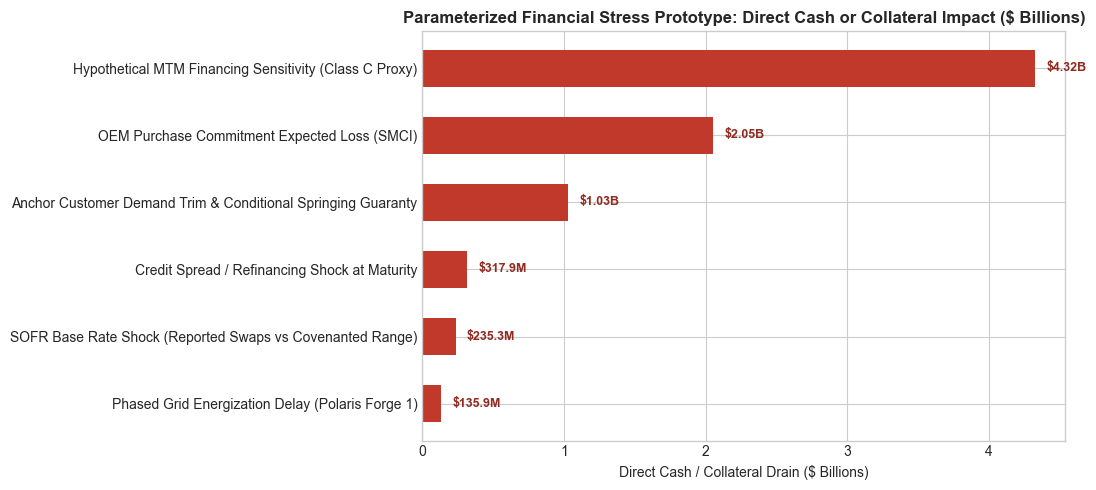

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
stress_plot = stress_summary.sort_values(by="direct_cash_or_collateral_hit_usd", ascending=True)
bars = ax.barh(stress_plot["scenario_name"], stress_plot["direct_cash_or_collateral_hit_usd"] / 1e9, color="#c0392b", height=0.55)
ax.set_title("Parameterized Financial Stress Prototype: Direct Cash or Collateral Impact ($ Billions)", fontsize=12, fontweight="bold")
ax.set_xlabel("Direct Cash / Collateral Drain ($ Billions)")

for bar in bars:
    w = bar.get_width()
    lbl = f"${w:.2f}B" if w >= 1.0 else f"${w*1000:.1f}M"
    ax.text(w + 0.08, bar.get_y() + bar.get_height()/2, lbl, va="center", fontsize=9, fontweight="bold", color="#922b21")

plt.tight_layout()
plt.savefig(project_root / "outputs/figures/financial_stress_waterfall.png", dpi=300)
plt.show()


## 7. Verifiable Evidence Ledger (Audit Receipts)

Every contractual assertion in this notebook is backed by an audited SEC EDGAR citation in `data/processed/evidence_claims.parquet`.
Below are the exact verbatim excerpts and accession numbers proving the $11.0B Polaris Forge lease, the $35.551B debt structure, the SPV springing guarantees, the $34.2B SMCI commitments, the 95% swap covenants, and the 67% Microsoft concentration.


In [14]:
claims_df = pd.read_parquet(project_root / "data/processed/evidence_claims.parquet")
claims_df[["claim_id", "entity_id", "filing_type", "filing_date", "section_locator", "exact_quote", "evidence_class"]]


,claim_id,entity_id,filing_type,filing_date,section_locator,exact_quote,evidence_class
0,CLM-APLD-001,APLD,10-K,2026-07-29,Item 1. Business - Data Center Leases,"On May 28, 2025, our subsidiaries APLD ELN-02 LLC and APLD ELN-03 LLC each entered into a data center lease",A
1,CLM-APLD-002,APLD,10-K,2026-07-29,Note 14. Commitments and Contingencies - Data Center Leases,"Also on March 30, 2026, CoreWeave entered into an Assignment, Assumption and Consent Agreement with CoreWeave SPV an...",A
2,CLM-APLD-003,APLD,10-K,2026-07-29,Note 8. Financing Arrangements and Notes Payable,"The Company's indebtedness includes $2,350.0 million aggregate principal amount of 9.25% Senior Secured Notes due 20...",A
3,CLM-APLD-004,APLD,10-K,2026-07-29,Item 1. Business - Campus Construction Phasing,"HPC data center at the campus, with approximately 100 MW of critical IT load, became operational in October 2025. A ...",A
4,CLM-APLD-005,APLD,8-K/A,2026-04-01,Exhibit 10.1 - Unconditional Springing Guaranty Agreement (APLD ELN-02 LLC),"As used herein, the term ""Springing Events"" shall include the following: (i) the receipt by the Equipment Financing ...",A
5,CLM-APLD-006,APLD,8-K/A,2026-04-01,Exhibit 10.2 - Unconditional Springing Guaranty Agreement (APLD ELN-03 LLC),"As used herein, the term ""Springing Events"" shall include the following: (i) the receipt by the Equipment Financing ...",A
6,CLM-APLD-007,APLD,10-K,2026-07-29,Note 19. Subsequent Events - 7.00% Senior Secured Notes Offering and Bridge Extinguishment,"On June 16, 2026, APLD ComputeCo 3 refinanced the Bridge Facility with the closing of a $1.59 billion offering (the ...",A
7,CLM-APLD-008,APLD,8-K,2026-06-16,Item 1.01 Entry into a Material Definitive Agreement / Item 2.03,"On June 16, 2026, APLD ComputeCo 3 LLC (the ""Issuer""), a subsidiary of Applied Digital Corporation (the ""Company"" or...",A
8,CLM-APLD-009,APLD,8-K,2025-06-02,Item 1.01 Entry into a Material Definitive Agreement,"On May 28, 2025, subsidiaries of Applied Digital Corporation entered into 15-year lease agreements with CoreWeave, I...",A
9,CLM-APLD-010,APLD,8-K,2024-06-17,Item 8.01 Other Events,"On June 14, 2024, APLD ComputeCo LLC completed the offering of $2,350.0 million aggregate principal amount of 9.250%...",A


## 8. Synthesis & Computational Sketchbook Findings

### What Phase 0 Epistemic Certification Established
1. **The Bubble Lives in the Joins:** On consolidated statements, Applied Digital appears as a standalone host with $1.59B in cash and $4.98B carrying debt. But through the join at Polaris Forge 1 ($11.0B 15-year lease with CoreWeave), APLD's cash flows are tied to CoreWeave's solvency.
2. **Perimeter Opacity & Uncapped Springing Guarantees:** CoreWeave executed separate Unconditional Springing Guarantees under Exhibit 10.1 (Building 2 Phase 2/4 Space, 2 of 4 halls; uncapped face value) and Exhibit 10.2 (Building 3, 150 MW; uncapped indemnity with $4.13B Class C reference proxy). If the Colocation Customer defaults or reduces payments, Springing Event (ii) activates parent liability. Building 4 ($4.13B, 150 MW) is guaranteed by APLD, not CoreWeave parent.
3. **Debt Decomposition & Duality:** Reconciled CoreWeave's indebtedness to $35.551B across 16 discrete modeled debt tranches/edges with 0.00% drift. Reconciled Applied Digital's debt duality: $4.976B net carrying balance sheet debt vs $5.307B gross contractual principal across 5 real instruments ($2.35B PF1, $2.15B PF2, $450M convertible, $300M floating bridge, $56.7M other) superseded by $1.59B 7.00% Senior Notes.
4. **Rate Transmission Grounded in Swaps:** Anchored on CoreWeave's audited $4.66B interest rate swap notional, revealing that $7.55B in floating debt is unhedged, plus APLD's $300M floating bridge facility, generating an immediate $235.4M/yr network cash drain (sensitivity band: $27.3M to $303.9M/yr). Maturing debt faces a $317.9M/yr refinancing penalty by 2027.
5. **Modeled Refinancing Gap vs Cash Calls:** A -40% GPU collateral haircut models a $4.32B refinancing capacity contraction (Class C proxy) rather than an automatic cash call; CoreWeave's cash remains $5.52B intact under DDTL 5.0 §2.05.
6. **Building-Level Operational Phasing:** Modeled Polaris Forge 1 building phasing (~150 MW operational producing $275M base rent vs ~250 MW pending expansion), with carrying costs evaluated across a sensitivity band of 6.8% to 9.4% of cash.
7. **Accounting vs. Cash Liquidity Separation:** Rigorously separated Supermicro's non-cash $2.05B NRV loss provision on equity from working capital inventory cash outflows ($769M cancellation fee vs $5.13B delivery).
